<a href="https://colab.research.google.com/github/harshchaturkar/Mini-Project-repo/blob/main/assignment_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import make_blobs
x, y_test = make_blobs(n_samples=500, centers=4, cluster_std=0.70)

In [ ]:
df = pd.DataFrame(x, columns=["Feature1","Feature2"])
df.head(10)

,Feature1,Feature2
0,9.688197,-8.917849
1,-0.203763,7.151390
2,-6.917638,8.077549
3,-1.252233,4.093447
4,-0.384755,4.870256
5,-6.745876,7.611760
6,9.431309,-9.817223
7,0.607457,7.649353
8,9.829644,-9.882789
9,1.028931,8.191119


In [ ]:
df.shape

(500, 2)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled[:5]

array([[ 1.51015899, -1.60012517],
       [-0.08924371,  0.6251504 ],
       [-1.17479088,  0.75340536],
       [-0.25876775,  0.2016851 ],
       [-0.11850775,  0.30925796]])

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
print(df.head(10))

   Feature1  Feature2  Cluster
0  9.688197 -8.917849        1
1 -0.203763  7.151390        2
2 -6.917638  8.077549        0
3 -1.252233  4.093447        2
4 -0.384755  4.870256        2
5 -6.745876  7.611760        0
6  9.431309 -9.817223        1
7  0.607457  7.649353        2
8  9.829644 -9.882789        1
9  1.028931  8.191119        2


Text(0.5, 1.0, 'KMeans Clusters')

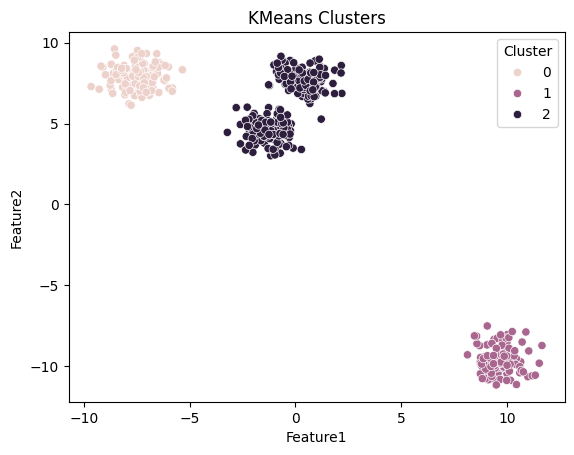

In [ ]:
sns.scatterplot(x="Feature1", y="Feature2", hue="Cluster", data=df)
plt.title("KMeans Clusters")

[1000.0000000000001, 139.46800150681216, 28.166340902289992, 11.385645292534107, 10.267469578023125, 8.980322188751861, 8.520978837279682, 7.191702077571839, 6.3314789949549555, 5.868792590253986]


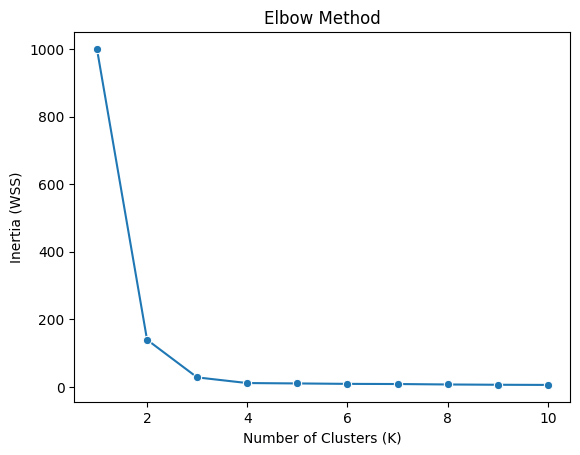

In [ ]:
Errors = []
k_value = range(1,11)

for k in k_value:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  Errors.append(kmeans.inertia_)
sns.lineplot(x=k_value, y=Errors, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
print(Errors)

In [ ]:
print("From the Elbow Method graph, the optimal number of clusters is K = 4.")
print("The elbow point appears at K = 4 because the inertia decreases rapidly up to this point and then the improvement becomes smaller.")
print("Therefore, K = 4 is selected as the optimal number of clusters.")

From the Elbow Method graph, the optimal number of clusters is K = 4.
The elbow point appears at K = 4 because the inertia decreases rapidly up to this point and then the improvement becomes smaller.
Therefore, K = 4 is selected as the optimal number of clusters.


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
1    125
3    125
0    125
2    125
Name: count, dtype: int64


In [ ]:
print("The final KMeans model was trained with K = 4.")
print("Cluster labels were added to the DataFrame.")
print("The number of data points in each cluster is displayed above.")

The final KMeans model was trained with K = 4.
Cluster labels were added to the DataFrame.
The number of data points in each cluster is displayed above.


Text(0.5, 1.0, 'KMeans Clusters')

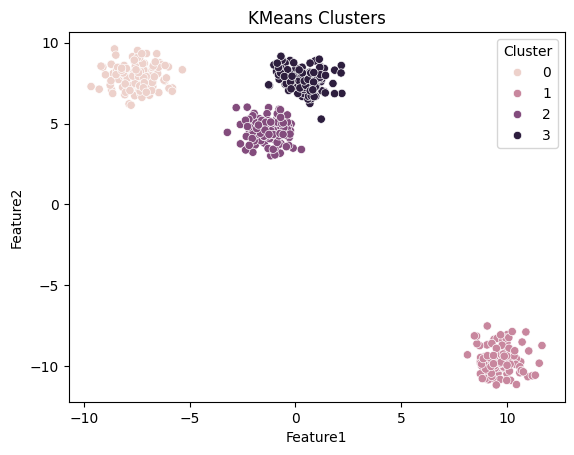

In [ ]:
sns.scatterplot(x="Feature1", y="Feature2", hue="Cluster", data=df)
plt.title("KMeans Clusters")

In [ ]:
sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    palette="viridis"
)

centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color="red",
    marker="X",
    s=200,
    label="Centroids"
)
plt.title("KMeans Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

ValueError: Could not interpret value `Cluster` for `hue`. An entry with this name does not appear in `data`.

In [ ]:
data = pd.read_csv("./Mall_Customers.csv")
data

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

num_cols = data.select_dtypes(exclude="object")
print("Numerical Columns")
print(num_cols.columns)
scaler = StandardScaler()
scaled = scaler.fit_transform(num_cols)
print("\nScaled Feature")
print(scaled[:5])

km = KMeans(n_clusters=5)
cluster = km.fit_predict(scaled)

data["Cluster"] = cluster
print("\n",data.head(10))
print("\n",data["Cluster"].value_counts())

Numerical Columns
Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

Scaled Feature
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]

     Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0    Male   19                  15                      39        3
1    Male   21                  15                      81        3
2  Female   20                  16                       6        3
3  Female   23                  16                      77        3
4  Female   31                  17                      40        3
5  Female   22                  17                      76        3
6  Female   35                  18                       6        1
7  Female   23                  18                      94        3
8    Male   64                  19                       3        4
9  Female

[599.9999999999999, 389.38618895643714, 295.4562449213557, 205.22514747675913, 169.89149793438568, 134.35277477401493, 121.38935022502866, 113.72723000071333, 102.13623844329251, 92.55027231838784]


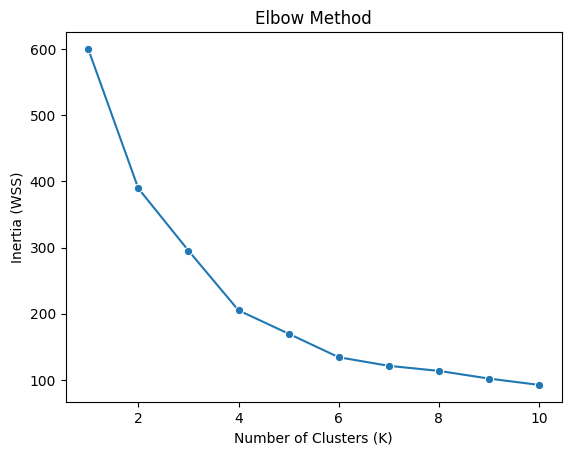

In [ ]:
inertia = []
K_value = range(1,11)

for K in K_value:
  km = KMeans(n_clusters=K, random_state=42)
  km.fit(scaled)
  inertia.append(km.inertia_)
sns.lineplot(x=K_value, y=inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
print(inertia)

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
data["Cluster"] = kmeans.fit_predict(scaled)

print("Cluster sizes")
print(data["Cluster"].value_counts())

Cluster sizes
Cluster
0    58
3    45
1    40
4    31
2    26
Name: count, dtype: int64


In [ ]:
data_2 = pd.read_csv("./Wholesale customers data.csv")
data_2

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


Numerical Columns
Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

Scaled Feature
[3520.0000000000014, 2600.3756482224435, 2149.2839562217573, 1851.8408722743864, 1567.449355005607, 1446.434958635648, 1189.4373315151008, 1146.3938222781724, 1082.6398816370165, 969.1934595642873]


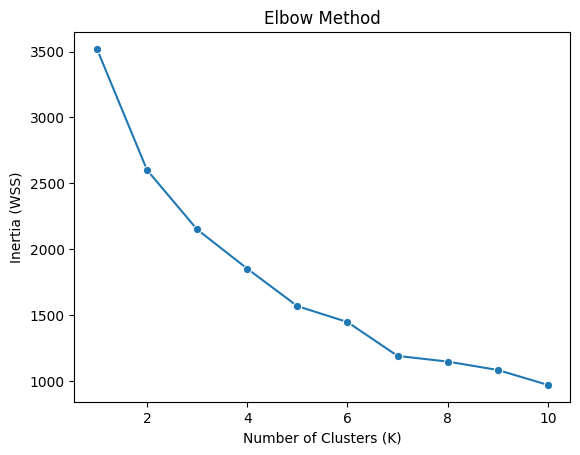

In [ ]:
num_cols = data_2.select_dtypes(exclude="object")
print("Numerical Columns")
print(num_cols.columns)
scaler = StandardScaler()
scaled_x = scaler.fit_transform(num_cols)
print("\nScaled Feature")
scaled[:5]

inertia = []
K_value = range(1,11)

for K in K_value:
  km = KMeans(n_clusters=K, random_state=42)
  km.fit(scaled_x)
  inertia.append(km.inertia_)

sns.lineplot(x=K_value, y=inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
print(inertia)

In [ ]:
print("From the above observation the optimal K = 7")

From the above observation the optimal K = 7


In [ ]:
km = KMeans(n_clusters=7, random_state=42)

data["Cluster"] = km.fit_predict(scaled)

In [ ]:
print(data["Cluster"].value_counts())

Cluster
0    44
1    39
6    37
4    27
2    23
5    21
3     9
Name: count, dtype: int64


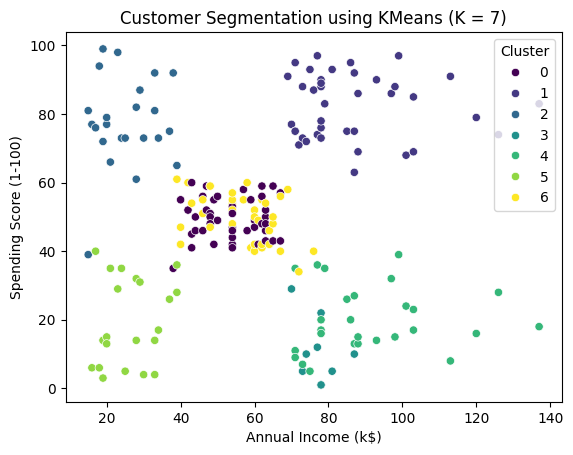

    Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0    Male   19                  15                      39        2
1    Male   21                  15                      81        2
2  Female   20                  16                       6        5
3  Female   23                  16                      77        2
4  Female   31                  17                      40        5
5  Female   22                  17                      76        2
6  Female   35                  18                       6        5
7  Female   23                  18                      94        2
8    Male   64                  19                       3        5
9  Female   30                  19                      72        2


In [ ]:
sns.scatterplot(
    data=data,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segmentation using KMeans (K = 7)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

print(data.head(10))